In [12]:
# importing all the modules needed
!pip install biopython
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib import colormaps
import pickle
import matplotlib.cm as cm
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SeqUtils import ProtParamData
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, confusion_matrix, precision_score, recall_score

In [2]:
# ectracting fasta sequences from ids
def extraction(file):
    seqs = {}
    current_id = ""
    for line in file:
        line = line.strip()
        if line.startswith(">"):
            current_id = line[1:]
            seqs[current_id] = ""
        else:
            seqs[current_id] += line
        # truncate each sequence to first 40 aa
        for k in seqs:
            seqs[k] = seqs[k][:40]
    return seqs

aa_list = list("ACDEFGHIKLMNPQRSTVWY")

# read FASTA files 
with open("pos_cluster-results_rep_seq.fasta", 'r') as pos_file:
    pos = extraction(pos_file)
with open("neg_cluster-results_rep_seq.fasta", 'r') as neg_file:
    neg = extraction(neg_file)


 Fold 1/5 
Train: ['fold_ac', 'fold_ad', 'fold_ae'], Val: fold_ab, Test: fold_aa
Top 10 features by Gini:
      feature  importance
0      tm_max    0.193165
1   hydro_max    0.172208
2  hydro_mean    0.105657
3     tm_mean    0.100550
4   hydro_std    0.089451
5       sheet    0.039392
6   refr_mean    0.022355
7        AA_L    0.020401
8      charge    0.020058
9    refr_max    0.019415


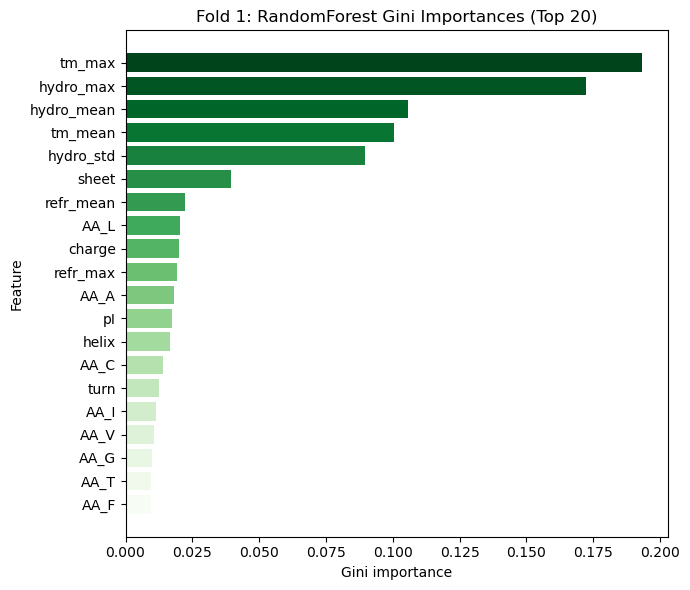

Best k = 23, Val Acc = 0.958


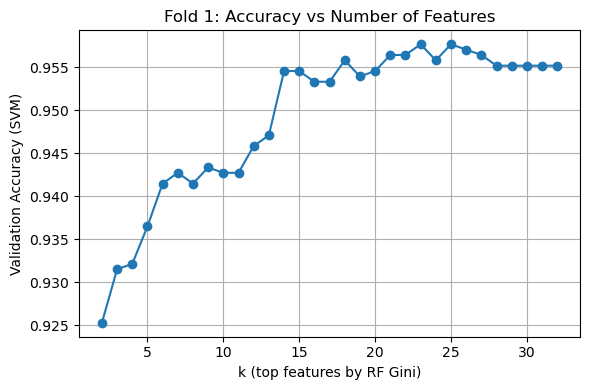

{'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}

Fold 1 results:
  All features -> Acc=0.944, F1=0.740, MCC=0.709, precision=0.757, recall=  0.723
  Selected (23) -> Acc=0.955, F1=0.788, MCC=0.763, precision=0.810, recall=  0.768


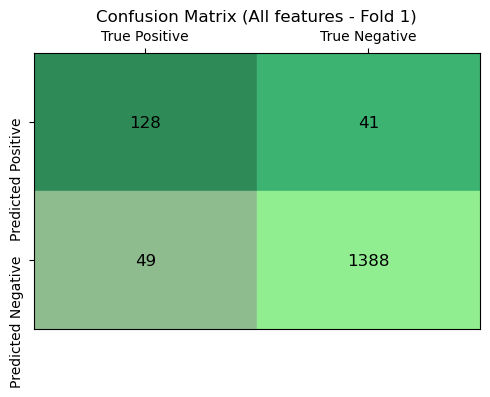

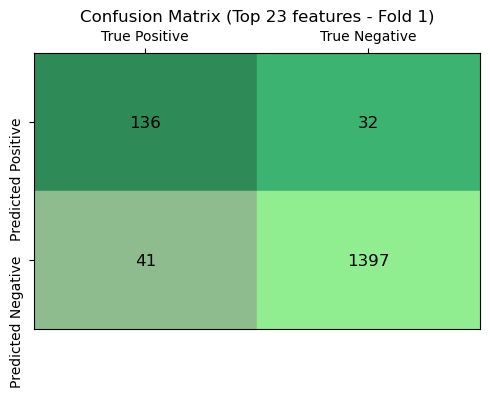


 Fold 2/5 
Train: ['fold_aa', 'fold_ad', 'fold_ae'], Val: fold_ac, Test: fold_ab
Top 10 features by Gini:
      feature  importance
0      tm_max    0.187369
1   hydro_max    0.173545
2     tm_mean    0.105260
3  hydro_mean    0.097884
4   hydro_std    0.078967
5       sheet    0.039350
6      charge    0.022021
7   refr_mean    0.021081
8        AA_L    0.020940
9    refr_max    0.019691


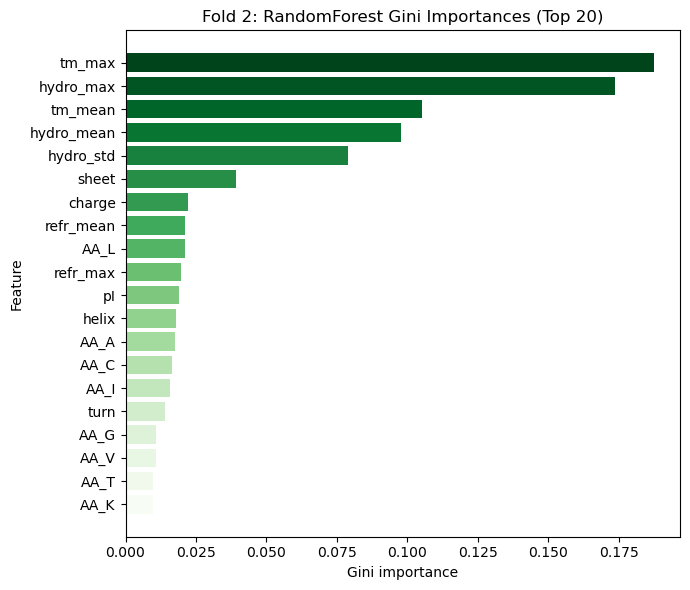

Best k = 25, Val Acc = 0.962


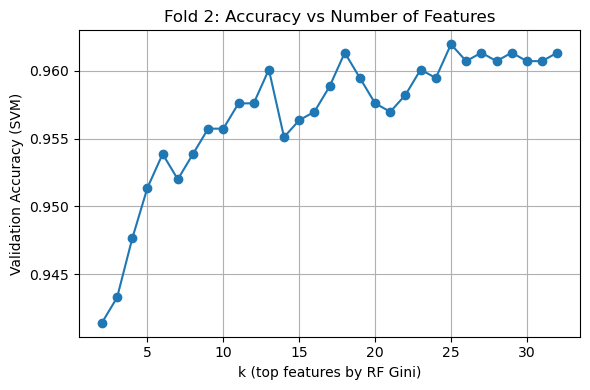

{'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}

Fold 2 results:
  All features -> Acc=0.955, F1=0.781, MCC=0.755, precision=0.774, recall=  0.788
  Selected (25) -> Acc=0.957, F1=0.792, MCC=0.768, precision=0.789, recall=  0.794


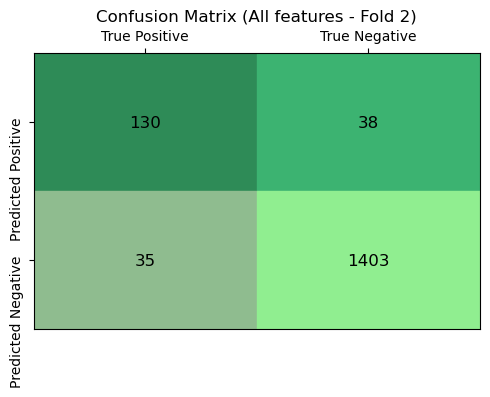

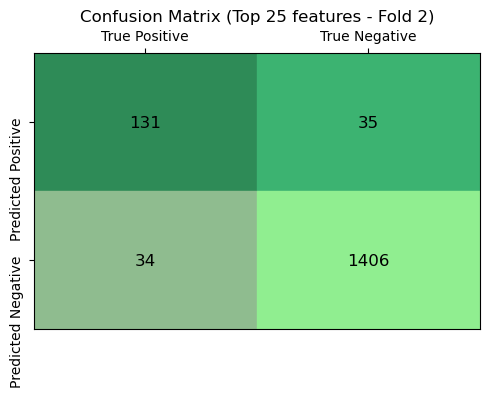


 Fold 3/5 
Train: ['fold_aa', 'fold_ab', 'fold_ae'], Val: fold_ad, Test: fold_ac
Top 10 features by Gini:
      feature  importance
0      tm_max    0.191443
1   hydro_max    0.159674
2     tm_mean    0.105727
3  hydro_mean    0.094763
4   hydro_std    0.076974
5       sheet    0.038972
6      charge    0.025262
7        AA_L    0.025213
8          pI    0.024373
9   refr_mean    0.021003


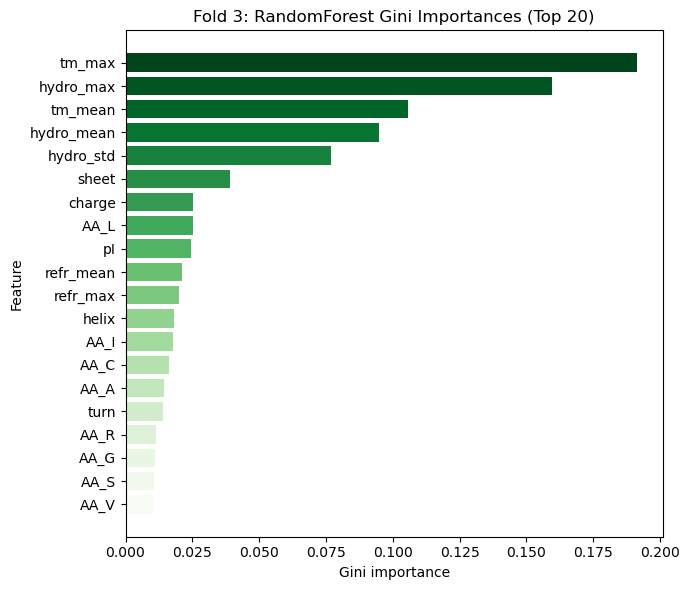

Best k = 25, Val Acc = 0.958


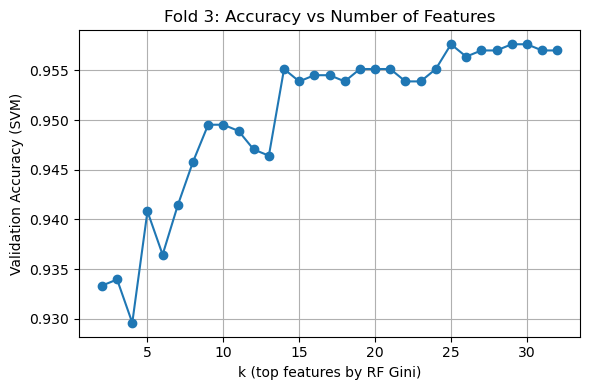

{'C': 1.0, 'gamma': 0.01, 'kernel': 'rbf'}

Fold 3 results:
  All features -> Acc=0.964, F1=0.841, MCC=0.821, precision=0.844, recall=  0.839
  Selected (25) -> Acc=0.967, F1=0.852, MCC=0.834, precision=0.855, recall=  0.850


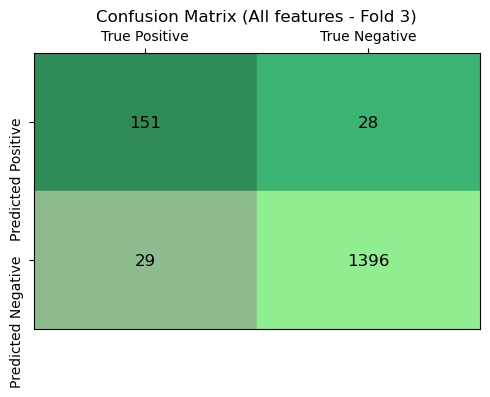

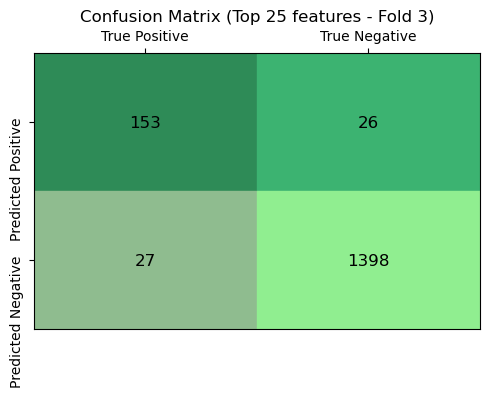


 Fold 4/5 
Train: ['fold_aa', 'fold_ab', 'fold_ac'], Val: fold_ae, Test: fold_ad
Top 10 features by Gini:
      feature  importance
0      tm_max    0.192803
1   hydro_max    0.175781
2     tm_mean    0.099520
3  hydro_mean    0.094487
4   hydro_std    0.085867
5       sheet    0.035707
6          pI    0.023670
7        AA_L    0.023595
8      charge    0.021954
9   refr_mean    0.020493


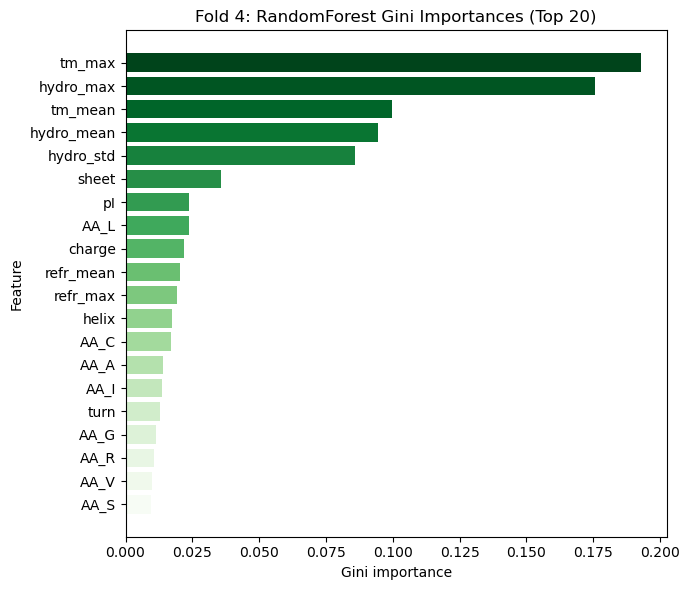

Best k = 25, Val Acc = 0.946


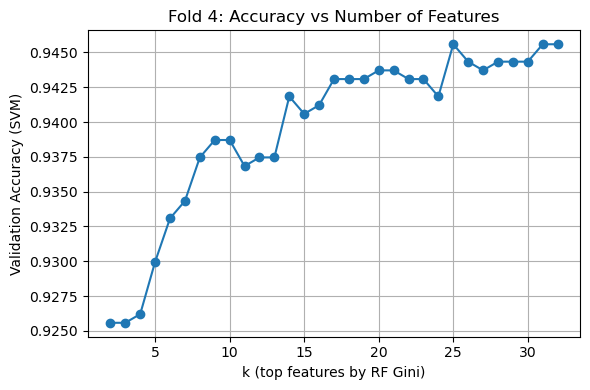

{'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}

Fold 4 results:
  All features -> Acc=0.955, F1=0.799, MCC=0.774, precision=0.767, recall=  0.833
  Selected (25) -> Acc=0.961, F1=0.822, MCC=0.800, precision=0.810, recall=  0.833


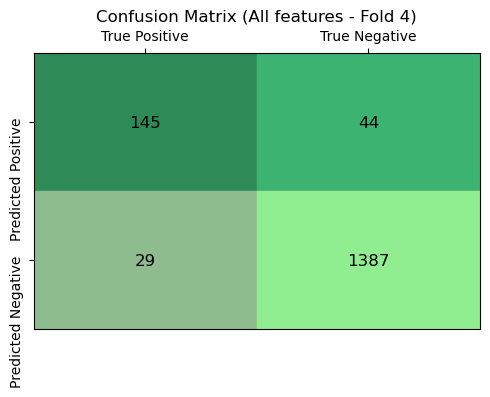

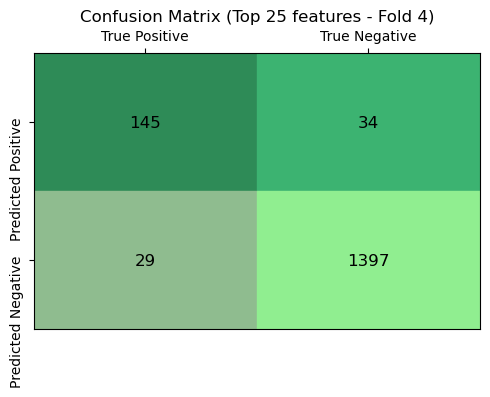


 Fold 5/5 
Train: ['fold_ab', 'fold_ac', 'fold_ad'], Val: fold_aa, Test: fold_ae
Top 10 features by Gini:
      feature  importance
0      tm_max    0.195524
1   hydro_max    0.176683
2     tm_mean    0.100586
3  hydro_mean    0.098672
4   hydro_std    0.085692
5       sheet    0.031035
6      charge    0.023733
7        AA_L    0.022857
8   refr_mean    0.021803
9          pI    0.020813


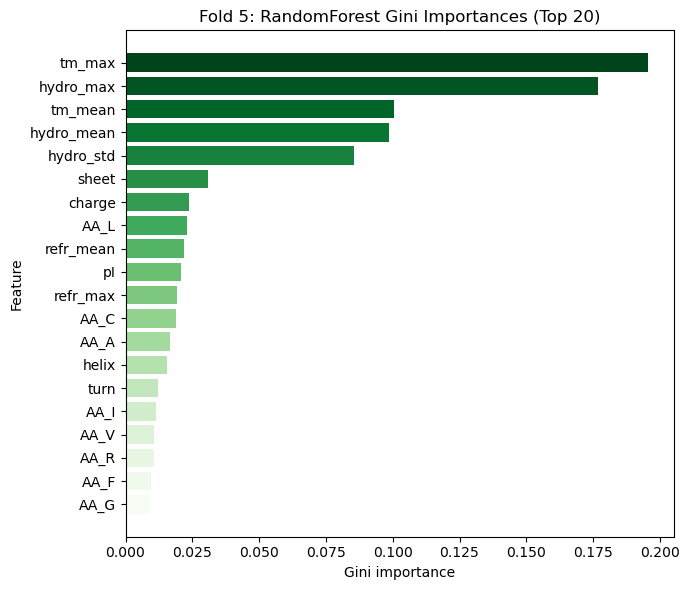

Best k = 31, Val Acc = 0.947


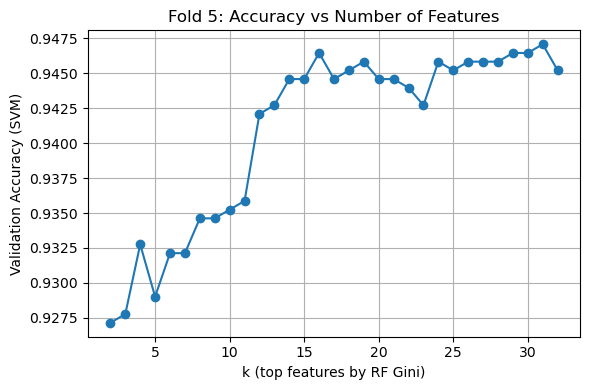

{'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}

Fold 5 results:
  All features -> Acc=0.947, F1=0.756, MCC=0.727, precision=0.767, recall=  0.746
  Selected (31) -> Acc=0.953, F1=0.783, MCC=0.757, precision=0.804, recall=  0.763


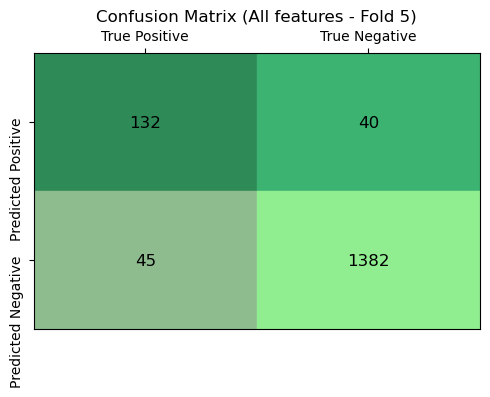

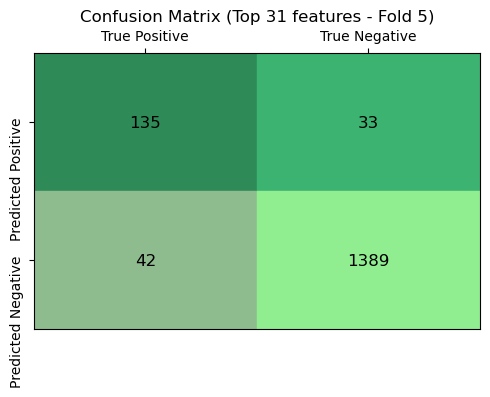


--------SUMMARY CV --------
   fold   k    C  gamma kernel   acc_all   acc_sel    f1_all    f1_sel  \
0     1  23  1.0  scale    rbf  0.943960  0.954545  0.739884  0.788406   
1     2  25  1.0  scale    rbf  0.954545  0.957036  0.780781  0.791541   
2     3  25  1.0   0.01    rbf  0.964464  0.966958  0.841226  0.852368   
3     4  25  1.0  scale    rbf  0.954517  0.960748  0.798898  0.821530   
4     5  31  1.0  scale    rbf  0.946842  0.953096  0.756447  0.782609   

    mcc_all   mcc_sel  prec_all  prec_sel   rec_all   rec_sel  
0  0.708739  0.763289  0.757396  0.809524  0.723164  0.768362  
1  0.755465  0.767595  0.773810  0.789157  0.787879  0.793939  
2  0.821223  0.833769  0.843575  0.854749  0.838889  0.850000  
3  0.774147  0.799585  0.767196  0.810056  0.833333  0.833333  
4  0.726713  0.756664  0.767442  0.803571  0.745763  0.762712  

Average:
acc_all     0.952866
acc_sel     0.958477
f1_all      0.783447
f1_sel      0.807291
mcc_all     0.757257
mcc_sel     0.784180
prec_a

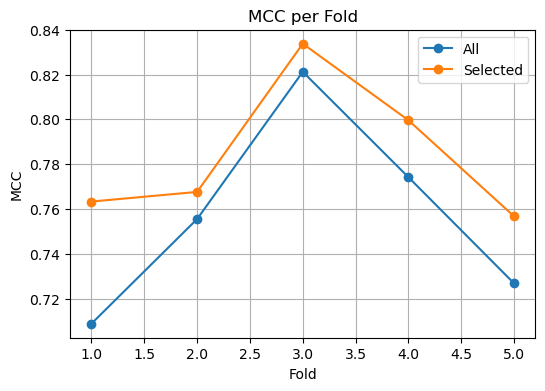

In [15]:
# FEATURE EXTRACTION 

# Transmembrane and refractivity scales
transmembrane_tendency_scale = {
    'A':  0.380, 'R': -2.570, 'N': -1.620, 'D': -3.270, 'C': -0.300,
    'Q': -1.840, 'E': -2.900, 'G': -0.190, 'H': -1.440, 'I':  1.970,
    'L':  1.820, 'K': -3.460, 'M':  1.400, 'F':  1.980, 'P': -1.440,
    'S': -0.530, 'T': -0.320, 'W':  1.530, 'Y':  0.490, 'V':  1.460
}

refractivity_scale = {
    'A':  4.340, 'R': 26.660, 'N': 13.280, 'D': 12.000, 'C': 35.770,
    'Q': 17.560, 'E': 17.260, 'G':  0.000, 'H': 21.810, 'I': 19.060,
    'L': 18.780, 'K': 21.290, 'M': 21.640, 'F': 29.400, 'P': 10.930,
    'S':  6.350, 'T': 11.010, 'W': 42.530, 'Y': 31.530, 'V': 13.920
}

#  FUNCTIONS (to be used for CV)

def amino_acid_composition(sequence, truncate=40):
    aa_list = list("ACDEFGHIKLMNPQRSTVWY")
    sequence = sequence[:truncate]
    counts = [sequence.count(aa) / len(sequence) if len(sequence) > 0 else 0 for aa in aa_list]
    return counts

# Hydrophobicity (Kyte-Doolittle)
def hydro(sequence, window_size=7):
    seq = sequence[:40]                
    d = window_size // 2
    seq = f"{'X'*d}{seq}{'X'*d}"       # padding
    seq = seq.replace("X", "G")        

    pa = ProteinAnalysis(seq)
    profile = pa.protein_scale(ProtParamData.kd, window_size)
    return [np.mean(profile), np.max(profile), np.std(profile)]

# Secondary structure fraction
def secondary_str(sequence):
    seq = sequence[:40]
    pa = ProteinAnalysis(seq)
    helix, turn, sheet = pa.secondary_structure_fraction()
    return [helix, turn, sheet]

# TM and refractivity sliding windows
def scale_features(sequence, scale, window_size=7):
    seq = sequence[:40]
    d = window_size // 2
    seq = f"{'X'*d}{seq}{'X'*d}"
    seq = seq.replace("X", "G")

    pa = ProteinAnalysis(seq)
    profile = pa.protein_scale(scale, window_size)
    return [np.mean(profile), np.max(profile)]


# MAIN MATRIX BUILDER 

def build_feature_matrix(pos_dict, neg_dict):

    X = []
    y = []
    seq_ids = []

    for label, seq_dict in zip([1, 0], [pos_dict, neg_dict]):
        for seq_id, seq in seq_dict.items():

            try:
                aa = amino_acid_composition(seq)
                hydro_feats = hydro(seq)
                ss_feats = secondary_str(seq)
                pa = ProteinAnalysis(seq[:40])
                pI = pa.isoelectric_point()
                charge = pa.charge_at_pH(7.0)
                tm_feats = scale_features(seq, transmembrane_tendency_scale)
                refr_feats = scale_features(seq, refractivity_scale)

                feature_vector = np.concatenate([
                    aa, hydro_feats, ss_feats,
                    [pI, charge],
                    tm_feats, refr_feats
                ])

                X.append(feature_vector)
                y.append(label)
                seq_ids.append(seq_id)

            except Exception as e:
                print(f"Error processing {seq_id}: {e}")

    aa_names = [f"AA_{aa}" for aa in "ACDEFGHIKLMNPQRSTVWY"]
    feature_names = aa_names + [
        "hydro_mean", "hydro_max", "hydro_std",
        "helix", "turn", "sheet",
        "pI", "charge",
        "tm_mean", "tm_max",
        "refr_mean", "refr_max"
    ]

    df = pd.DataFrame(X, columns=feature_names)
    df["label"] = y
    df["seq_id"] = seq_ids

    return df, feature_names

# saving the df in an npz file
df, feature_names = build_feature_matrix(pos, neg)
np.savez(
    "training_features.npz",
    X=df[feature_names].values,
    y=df["label"].values,
    seq_ids=df["seq_id"].values,
    feature_names=np.array(feature_names, dtype=object)
)

# SVM PIPELINE

def svm_pipeline(C, gamma, kernel="linear", degree=3, coef0=0.0):
    return SVC(kernel=kernel, C=C, gamma=gamma, degree=degree, coef0=coef0, random_state=42)

def plot_confusion_matrix_custom(y_true, y_pred, round_num, features, tag=""):
    cm_ = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm_.ravel()
    plot_cm = np.array([[TP, FP], [FN, TN]])

    cell_colors = np.array([
        ['seagreen', 'mediumseagreen'],
        ['darkseagreen', 'lightgreen']
    ])

    fig, ax = plt.subplots(figsize=(5, 4))
    for r in range(2):
        for c in range(2):
            ax.add_patch(plt.Rectangle((c, 1-r), 1, 1, color=cell_colors[r, c]))
            text_color = 'black' if (r, c) == (0, 0) else 'white'
            ax.text(c+0.5, 1.5-r, plot_cm[r, c], ha='center', va='center', fontsize=12)

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(['True Positive', 'True Negative'])
    ax.xaxis.tick_top()
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['Predicted Negative', 'Predicted Positive'], rotation=90)
    ax.set_title(f'Confusion Matrix ({features} - Fold {round_num})')

    plt.tight_layout()
    if features == "All features":
        plt.savefig(f"CM_fold{round_num}_ALL.png")
    else:
        plt.savefig(f"CM_fold_{round_num}_selected_feature.png")
    plt.show()

#   CV PIPELINE STARTS 
best_params_base = {"C": 10, "gamma": 0.1, "kernel": "linear"}
C_grid = [0.1, 1.0, 10.0, 100.0]
gamma_grid = ["scale", 0.01, 0.1, 1.0]
kernels = ["linear", "rbf", "poly", "sigmoid"]

fold_metrics = []
fold_conf_mats = []
k_curves = []

fold_files = ["fold_aa", "fold_ab", "fold_ac", "fold_ad", "fold_ae"]
fold_data = {}

# load fold
for file_name in fold_files:
    with open(file_name, 'r') as f:
        seq_ids = [line.strip() for line in f if line.strip()]
    fold_data[file_name] = seq_ids

#  CROSS-VALIDATION 

for i, test_fold in enumerate(fold_files):

    val_fold = fold_files[(i + 1) % len(fold_files)]
    train_folds = [f for f in fold_files if f not in [test_fold, val_fold]]

    print(f"\n Fold {i+1}/{len(fold_files)} ")
    print(f"Train: {train_folds}, Val: {val_fold}, Test: {test_fold}")

    train_ids = [sid for f in train_folds for sid in fold_data[f]]
    val_ids   = fold_data[val_fold]
    test_ids  = fold_data[test_fold]

    train_df = df[df["seq_id"].isin(train_ids)]
    val_df   = df[df["seq_id"].isin(val_ids)]
    test_df  = df[df["seq_id"].isin(test_ids)]

    X_train, y_train = train_df[feature_names].values, train_df["label"].values
    X_val,   y_val   = val_df[feature_names].values,   val_df["label"].values
    X_test,  y_test  = test_df[feature_names].values,  test_df["label"].values

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)

    # RF ranking
    rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
    rf.fit(X_train_s, y_train)

    gini_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
    gini_df = gini_imp.reset_index()
    gini_df.columns = ["feature", "importance"]

    print("Top 10 features by Gini:")
    print(gini_df.head(10))
    gini_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
    gini_df = gini_imp.reset_index()
    gini_df.columns = ["feature", "importance"]

    #  Plot top 20 Gini importances
    plt.figure(figsize=(7, 6))
    colors = cm.Greens(np.linspace(0, 1, 20))
    plt.barh(gini_df["feature"].head(20)[::-1], gini_df["importance"].head(20)[::-1], color=colors[0::])
    plt.xlabel("Gini importance")
    plt.ylabel("Feature")
    
    plt.title(f"Fold {i+1}: RandomForest Gini Importances (Top 20)")
    plt.tight_layout()
    plt.savefig(f"RF_Gini_fold{i+1}.png", dpi=200, bbox_inches='tight')
    plt.show()

    # Try different k values
    ks = list(range(2, min(101, X_train.shape[1] + 1)))
    curve = []

    for k in ks:
        subset = gini_df["feature"].head(k).tolist()
        idx = [feature_names.index(f) for f in subset]
        Xtr, Xva = X_train_s[:, idx], X_val_s[:, idx]

        model = svm_pipeline(best_params_base["C"], best_params_base["gamma"])
        model.fit(Xtr, y_train)
        val_acc = accuracy_score(y_val, model.predict(Xva))
        curve.append(val_acc)

    best_k_idx = int(np.argmax(curve))
    best_k = ks[best_k_idx]
    print(f"Best k = {best_k}, Val Acc = {curve[best_k_idx]:.3f}")

    # Plot accuracy vs k
    plt.figure(figsize=(6, 4))
    plt.plot(ks, curve, marker="o")
    plt.xlabel("k (top features by RF Gini)")
    plt.ylabel("Validation Accuracy (SVM)")
    plt.title(f"Fold {i+1}: Accuracy vs Number of Features")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"acc_vs_features_fold{i+1}.png", dpi=200, bbox_inches='tight')
    plt.show()

    # Recompute selected features
    best_subset = gini_df["feature"].head(best_k).tolist()
    idx = [feature_names.index(f) for f in best_subset]
    Xtr_sel, Xva_sel, Xte_sel = X_train_s[:, idx], X_val_s[:, idx], X_test_s[:, idx]

    # kernel and grid search C, gamma
    best_score_sel = -np.inf
    best_params_sel = None

    for kernel in kernels:
        for C in C_grid:
            for gamma in gamma_grid:
                pipe = svm_pipeline(C, gamma, kernel=kernel)
                pipe.fit(Xtr_sel, y_train)
                val_acc = accuracy_score(y_val, pipe.predict(Xva_sel))
                
                if val_acc > best_score_sel:
                    best_score_sel = val_acc
                    best_params_sel = {"C": C, "gamma": gamma, "kernel": kernel}

    print(best_params_sel)

    final_svm = svm_pipeline(best_params_sel["C"], best_params_sel["gamma"], kernel=best_params_sel["kernel"])
    final_svm.fit(Xtr_sel, y_train)
    y_pred_sel = final_svm.predict(Xte_sel)

    f1_sel = f1_score(y_test, y_pred_sel)
    mcc_sel = matthews_corrcoef(y_test, y_pred_sel)
    acc_sel = accuracy_score(y_test, y_pred_sel)
    prec_sel = precision_score(y_test, y_pred_sel)
    rec_sel  = recall_score(y_test, y_pred_sel)

    # Baseline SVM (all features)
    base_svm = svm_pipeline(best_params_base["C"], best_params_base["gamma"], kernel=best_params_base["kernel"])
    base_svm.fit(X_train_s, y_train)
    y_pred_all = base_svm.predict(X_test_s)

    f1_all = f1_score(y_test, y_pred_all)
    mcc_all = matthews_corrcoef(y_test, y_pred_all)
    acc_all = accuracy_score(y_test, y_pred_all)
    prec_all = precision_score(y_test, y_pred_all)
    rec_all  = recall_score(y_test, y_pred_all)


    print(f"\nFold {i+1} results:")
    print(f"  All features -> Acc={acc_all:.3f}, F1={f1_all:.3f}, MCC={mcc_all:.3f}, precision={prec_all:.3f}, recall= {rec_all: .3f}")
    print(f"  Selected ({best_k}) -> Acc={acc_sel:.3f}, F1={f1_sel:.3f}, MCC={mcc_sel:.3f}, precision={prec_sel:.3f}, recall= {rec_sel: .3f}")

    plot_confusion_matrix_custom(y_test, y_pred_all, i+1, "All features")
    plot_confusion_matrix_custom(y_test, y_pred_sel, i+1, f"Top {best_k} features")

    fold_metrics.append({
        "fold": i+1,
        "k": best_k,
        "k": best_k,
        "C": best_params_sel["C"],
        "gamma": best_params_sel["gamma"],
        "kernel": best_params_sel["kernel"],
        "acc_all": acc_all,
        "acc_sel": acc_sel,
        "f1_all": f1_all,
        "f1_sel": f1_sel,
        "mcc_all": mcc_all,
        "mcc_sel": mcc_sel,
        "prec_all": prec_all,
        "prec_sel": prec_sel,
        "rec_all": rec_all,
        "rec_sel": rec_sel
    })

# SUMMARY 

metrics_df = pd.DataFrame(fold_metrics)
print("\n--------SUMMARY CV --------")
print(metrics_df)

print("\nAverage:")
print(metrics_df[["acc_all","acc_sel","f1_all","f1_sel","mcc_all","mcc_sel", "prec_all", "prec_sel", "rec_all", "rec_sel"]].mean())

plt.figure(figsize=(6, 4))
plt.plot(metrics_df["fold"], metrics_df["mcc_all"], 'o-', label="All")
plt.plot(metrics_df["fold"], metrics_df["mcc_sel"], 'o-', label="Selected")
plt.xlabel("Fold")
plt.ylabel("MCC")
plt.legend()
plt.title("MCC per Fold")
plt.grid()
plt.savefig("MCC_PER_FOLD.png")
plt.show()


In [11]:
# saving the results to be used for training the whole model and for benchmark set:

best_k = int(np.round(np.mean([m["k"] for m in fold_metrics])))
    
# extract all C / gamma / kernel values used in the SELECTED features SVM per fold

C_list = [m["C"] for m in fold_metrics if "C" in m and m["C"] is not None]
gamma_list = [m["gamma"] for m in fold_metrics if "gamma" in m and m["gamma"] is not None]
kernel_list = [m["kernel"] for m in fold_metrics if "kernel" in m and m["kernel"] is not None]
    
best_C = float(np.median(C_list))
best_gamma = Counter(gamma_list).most_common(1)[0][0]
best_kernel = Counter(kernel_list).most_common(1)[0][0]

print("Best k =", best_k)
print("Best C =", best_C)
print("Best gamma =", best_gamma)
print("Best kernel =", best_kernel)

cv_summary = {
        "best_k": best_k,
        "best_C": best_C,
        "best_gamma": best_gamma,
        "best_kernel": best_kernel,
        "per_fold": fold_metrics
    }
    
np.save("cv_results.npy", cv_summary)

Best k = 26
Best C = 1.0
Best gamma = scale
Best kernel = rbf
